# causal/04 SCM 合成控制 实战

数据：California tobacco panel（Abadie-Diamond-Hainmueller 2010 JASA，39 州 x 31 年）
目标：用经典 SCM 估计 1989 年加州 99 号提案对人均卷烟销量的因果效应

三步法：
1. Pre-treatment fit：构造合成加州，处理前 1970-1988 与真实加州几乎重合
2. Post-treatment jump：处理后 1989-2000 加州真实 - 合成 = ATT
3. Placebo permutation：38 对照州做 placebo，估计 p-value

In [1]:
import io
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# California tobacco panel: Abadie-Diamond-Hainmueller (2010) JASA 105(490),
# 39 states x 31 years (1970-2000). Data embedded below so this notebook runs
# standalone (the articles/ tree is not published to GitHub). Original source:
#   https://raw.githubusercontent.com/Matt2371/Proposition99/main/Data/data.csv
CSV_TEXT = r"""state,year,cigsale,lnincome,beer,age15to24,retprice
Alabama,1970,89.8,,,0.17886178,39.6
Alabama,1971,95.4,,,0.17992784,42.7
Alabama,1972,101.1,9.498476,,0.1809939,42.3
Alabama,1973,102.9,9.550107,,0.18205994,42.1
Alabama,1974,108.2,9.537163,,0.183126,43.1
Alabama,1975,111.7,9.540031,,0.18419206,46.6
Alabama,1976,116.2,9.5919075,,0.18525812,50.4
Alabama,1977,117.1,9.617496,,0.18632418,50.1
Alabama,1978,123,9.654072,,0.18739022,55.1
Alabama,1979,121.4,9.64918,,0.18845628,56.8
Alabama,1980,123.2,9.612194,,0.18952234,60.6
Alabama,1981,119.6,9.609594,,0.18584223,68.8
Alabama,1982,119.1,9.59758,,0.18216212,73.1
Alabama,1983,116.3,9.626769,,0.17848201,84.4
Alabama,1984,113,9.671621,18,0.1748019,90.8
Alabama,1985,114.5,9.703193,18.7,0.17112179,99
Alabama,1986,116.3,9.74595,19.3,0.16744168,103
Alabama,1987,114,9.762092,19.4,0.16376157,110
Alabama,1988,112.1,9.78177,19.4,0.16008146,114.4
Alabama,1989,105.6,9.802527,19.4,0.15640135,122.3
Alabama,1990,108.6,9.81429,20.1,0.15272124,139.1
Alabama,1991,107.9,9.81926,20.1,,144.4
Alabama,1992,109.1,9.845286,20.4,,172.2
Alabama,1993,108.5,9.85216,20.3,,176.2
Alabama,1994,107.1,9.879334,21,,154.6
Alabama,1995,102.6,9.924404,20.6,,155.1
Alabama,1996,101.4,9.940027,21,,158.3
Alabama,1997,104.9,9.93727,20.8,,167.4
Alabama,1998,106.2,,,,180.5
Alabama,1999,100.7,,,,195.6
Alabama,2000,96.2,,,,270.7
Arkansas,1970,100.3,,,0.16900676,36.7
Arkansas,1971,104.1,,,0.16995385,38.8
Arkansas,1972,103.9,9.464514,,0.17090096,44.1
Arkansas,1973,108,9.55683,,0.17184804,45.1
Arkansas,1974,109.7,9.542286,,0.17279513,45.5
Arkansas,1975,114.8,9.514094,,0.17374223,48.6
Arkansas,1976,119.1,9.558153,,0.17468932,50.9
Arkansas,1977,122.6,9.590923,,0.17563641,52.6
Arkansas,1978,127.3,9.657238,,0.1765835,56.5
Arkansas,1979,126.5,9.6335335,,0.1775306,58.4
Arkansas,1980,131.8,9.573803,,0.17847769,61.5
Arkansas,1981,128.7,9.593041,,0.17501111,64.7
Arkansas,1982,127.4,9.5737,,0.17154454,72.1
Arkansas,1983,128,9.593053,,0.16807795,82
Arkansas,1984,123.1,9.65044,17.9,0.16461137,93.6
Arkansas,1985,125.8,9.675527,18.1,0.1611448,98.5
Arkansas,1986,126,9.705939,18.7,0.15767822,103.6
Arkansas,1987,122.3,9.705574,19,0.15421164,113
Arkansas,1988,121.5,9.721532,18.9,0.15074505,119.9
Arkansas,1989,118.3,9.7373705,19,0.14727847,127.7
Arkansas,1990,113.1,9.736311,19.9,0.1438119,141.2
Arkansas,1991,116.8,9.743068,19.9,,146.5
Arkansas,1992,126,9.788629,20,,177.3
Arkansas,1993,113.8,9.785142,19.7,,179.9
Arkansas,1994,108.8,9.813631,19.7,,168.1
Arkansas,1995,113,9.86446,19.5,,167.3
Arkansas,1996,110.7,9.885234,20.1,,167.1
Arkansas,1997,108.7,9.883107,19.8,,181.3
Arkansas,1998,109.5,,,,187.3
Arkansas,1999,104.8,,,,206.9
Arkansas,2000,99.4,,,,279.3
California,1970,123,,,0.17815833,38.8
California,1971,121,,,0.17929636,39.7
California,1972,123.5,9.930814,,0.18043439,39.9
California,1973,124.4,9.955092,,0.18157241,39.9
California,1974,126.7,9.947999,,0.18271044,41.9
California,1975,127.1,9.937167,,0.18384847,45
California,1976,128,9.976858,,0.1849865,48.3
California,1977,126.4,10.0027,,0.18612453,49
California,1978,126.1,10.045565,,0.18726255,58.7
California,1979,121.9,10.0546875,,0.18840058,60.1
California,1980,120.2,10.037841,,0.18953861,62.1
California,1981,118.6,10.028626,,0.18553706,66.4
California,1982,115.4,10.01253,,0.1815355,72.8
California,1983,110.8,10.031737,,0.17753394,84.9
California,1984,104.8,10.075359,25,0.17353238,94.9
California,1985,102.8,10.099703,24,0.16953082,98
California,1986,99.7,10.127267,24.7,0.16552927,104.4
California,1987,97.5,10.134301,24.1,0.16152771,103.9
California,1988,90.1,10.141663,23.6,0.15752615,117.4
California,1989,82.4,10.142313,23.7,0.15352459,126.4
California,1990,77.8,10.141623,23.8,0.14952303,163.8
California,1991,68.7,10.110714,22.3,,186.8
California,1992,67.5,10.114939,21.3,,201.9
California,1993,63.4,10.098497,20.8,,205.1
California,1994,58.6,10.099508,20.1,,190.3
California,1995,56.4,10.155916,19.7,,195.1
California,1996,54.5,10.178637,19.1,,197.9
California,1997,53.8,10.17519,19.5,,200.3
California,1998,52.3,,,,207.8
California,1999,47.2,,,,224.9
California,2000,41.6,,,,351.2
Colorado,1970,124.8,,,0.19095023,29.4
Colorado,1971,125.5,,,0.19164759,31.1
Colorado,1972,134.3,9.805548,,0.19234496,31.2
Colorado,1973,137.9,9.848413,,0.19304232,32.7
Colorado,1974,132.8,9.840451,,0.19373968,38.1
Colorado,1975,131,9.828461,,0.19443706,41.7
Colorado,1976,134.2,9.858913,,0.19513442,44.8
Colorado,1977,132,9.888447,,0.19583178,44.7
Colorado,1978,129.2,9.933751,,0.19652914,57.4
Colorado,1979,131.5,9.94222,,0.19722651,52.8
Colorado,1980,131,9.943612,,0.19792387,54.6
Colorado,1981,133.8,9.9572735,,0.19186871,58.1
Colorado,1982,130.5,9.962617,,0.18581356,61.4
Colorado,1983,125.3,9.978037,,0.1797584,73.3
Colorado,1984,119.7,10.002046,25.7,0.17370325,83.4
Colorado,1985,112.4,10.000779,25.2,0.16764809,93.1
Colorado,1986,109.9,10.001593,25.5,0.16159293,95.1
Colorado,1987,102.4,9.994427,24.8,0.15553778,108.6
Colorado,1988,94.6,10.018831,24.2,0.14948262,116
Colorado,1989,88.8,10.043063,23.9,0.14342748,130.8
Colorado,1990,87.4,10.046251,24.2,0.13737231,149.3
Colorado,1991,90.2,10.054761,23.5,,152.6
Colorado,1992,88.3,10.0663395,23.7,,157.5
Colorado,1993,88.6,10.079669,23.5,,168.2
Colorado,1994,89.1,10.097464,23.1,,153.2
Colorado,1995,85.4,10.16635,24.4,,164.2
Colorado,1996,83.1,10.191437,24.8,,169.6
Colorado,1997,81.3,10.2038965,24,,174.4
Colorado,1998,81.2,,,,185.8
Colorado,1999,79.6,,,,204.2
Colorado,2000,73,,,,281.3
Connecticut,1970,120,,,0.16292876,42.2
Connecticut,1971,117.6,,,0.1646539,45.5
Connecticut,1972,110.8,9.981137,,0.16637905,51.3
Connecticut,1973,109.3,10.012989,,0.16810419,50.6
Connecticut,1974,112.4,9.988535,,0.16982932,52.5
Connecticut,1975,110.2,9.960749,,0.17155448,54.5
Connecticut,1976,113.4,9.993227,,0.17327961,57.6
Connecticut,1977,117.3,10.028069,,0.17500475,58.4
Connecticut,1978,117.5,10.063203,,0.17672989,61.7
Connecticut,1979,117.4,10.075508,,0.17845504,64.4
Connecticut,1980,118,10.074763,,0.18018018,67
Connecticut,1981,116.4,10.079572,,0.17605005,80.1
Connecticut,1982,114.7,10.090163,,0.17191993,85.6
Connecticut,1983,114.1,10.12007,,0.16778982,95.6
Connecticut,1984,112.5,10.181597,20.3,0.16365969,113.5
Connecticut,1985,111,10.212917,20.8,0.15952957,118.6
Connecticut,1986,108.5,10.268609,20.6,0.15539944,118.5
Connecticut,1987,109,10.309229,21.1,0.15126932,122.7
Connecticut,1988,104.8,10.355395,20.7,0.1471392,129.7
Connecticut,1989,100.6,10.366524,19.8,0.14300908,142
Connecticut,1990,91.5,10.349302,19.8,0.13887896,171.2
Connecticut,1991,86.7,10.324137,18.7,,175.6
Connecticut,1992,83.5,10.3438425,18.3,,193.5
Connecticut,1993,79.1,10.343544,17.9,,202.3
Connecticut,1994,76.6,10.361299,17.9,,205.6
Connecticut,1995,79.3,10.451002,17.6,,205.4
Connecticut,1996,76,10.474495,17.2,,206.3
Connecticut,1997,75.9,10.486617,17.5,,208.5
Connecticut,1998,75.5,,,,217.9
Connecticut,1999,73.4,,,,236.5
Connecticut,2000,71.4,,,,312.3
Delaware,1970,155,,,0.17335767,39
Delaware,1971,161.1,,,0.17588721,41.3
Delaware,1972,156.3,9.90993,,0.17841677,44.7
Delaware,1973,154.7,9.948177,,0.18094632,44
Delaware,1974,151.3,9.918258,,0.18347588,44.2
Delaware,1975,147.6,9.887531,,0.18600543,45.9
Delaware,1976,153,9.920685,,0.18853498,50.1
Delaware,1977,153.3,9.933779,,0.19106454,51.7
Delaware,1978,155.5,9.944127,,0.19359408,58.7
Delaware,1979,150.2,9.926104,,0.19612364,60
Delaware,1980,150.5,9.913744,,0.19865319,62.7
Delaware,1981,152.6,9.901393,,0.19354601,66
Delaware,1982,154.1,9.904337,,0.18843885,74.1
Delaware,1983,149.6,9.934576,,0.18333167,82
Delaware,1984,144,9.962282,26.6,0.1782245,91.1
Delaware,1985,144.5,9.996334,26.2,0.17311732,98.7
Delaware,1986,142.4,10.032092,26,0.16801015,105.2
Delaware,1987,141,10.048571,25.9,0.16290298,111.4
Delaware,1988,137.1,10.077722,25.7,0.1577958,119.3
Delaware,1989,131.7,10.103605,24.9,0.15268864,124
Delaware,1990,127.2,10.094804,25.8,0.14758146,140
Delaware,1991,118.8,10.083064,24.9,,143.2
Delaware,1992,120,10.091464,25.2,,174.7
Delaware,1993,123.8,10.092083,26.2,,187.9
Delaware,1994,126.1,10.131247,25.9,,152.5
Delaware,1995,127.2,10.229653,24.6,,160.7
Delaware,1996,128.3,10.262393,24.6,,169.1
Delaware,1997,124.1,10.261678,24.9,,171.9
Delaware,1998,132.8,,,,179.2
Delaware,1999,139.5,,,,198.3
Delaware,2000,140.7,,,,276.2
Georgia,1970,109.9,,,0.1874455,34.3
Georgia,1971,115.7,,,0.18786626,35.8
Georgia,1972,117,9.63889,,0.18828699,40.9
Georgia,1973,119.8,9.684865,,0.18870774,42.4
Georgia,1974,123.7,9.659981,,0.18912847,42.4
Georgia,1975,122.9,9.629609,,0.18954922,44.5
Georgia,1976,125.9,9.67143,,0.18996997,47.9
Georgia,1977,127.9,9.693337,,0.1903907,49.5
Georgia,1978,130.6,9.736651,,0.19081146,54.7
Georgia,1979,131,9.729302,,0.19123219,56.6
Georgia,1980,134,9.701445,,0.19165294,59.3
Georgia,1981,131.7,9.704944,,0.18797573,62.6
Georgia,1982,131.2,9.707344,,0.18429853,67.8
Georgia,1983,128.6,9.755732,,0.18062133,78.9
Georgia,1984,126.3,9.82549,21.3,0.17694412,86.8
Georgia,1985,128.8,9.862127,21.4,0.17326692,90.7
Georgia,1986,129,9.913809,22.1,0.16958973,100.1
Georgia,1987,129.3,9.930798,22.3,0.16591252,103.9
Georgia,1988,124.1,9.952863,21.7,0.16223532,109.2
Georgia,1989,117.1,9.953909,21.5,0.15855812,122.4
Georgia,1990,113.8,9.953298,22.3,0.15488091,132.3
Georgia,1991,109.6,9.941865,21.2,,138.2
Georgia,1992,109.2,9.958565,21.6,,159.5
Georgia,1993,109.2,9.967873,21.7,,167.2
Georgia,1994,107.8,9.9982395,21.4,,147.8
Georgia,1995,100.3,10.055438,21.5,,153.8
Georgia,1996,102.7,10.079771,22,,156.1
Georgia,1997,100.6,10.081408,21.6,,158.9
Georgia,1998,100.5,,,,168.7
Georgia,1999,97.1,,,,188
Georgia,2000,88.4,,,,257.4
Idaho,1970,102.4,,,0.17812061,33.8
Idaho,1971,108.5,,,0.17609245,33.6
Idaho,1972,126.1,9.651839,,0.1740643,33.7
Idaho,1973,121.8,9.721051,,0.17203613,36.3
Idaho,1974,125.6,9.746263,,0.17000796,38
Idaho,1975,123.3,9.692201,,0.1679798,40.3
Idaho,1976,125.1,9.731101,,0.16595164,42.5
Idaho,1977,125,9.726507,,0.16392347,45.6
Idaho,1978,122.8,9.768933,,0.1618953,51.5
Idaho,1979,117.5,9.737336,,0.15986715,55.4
Idaho,1980,115.2,9.711496,,0.15783899,56.4
Idaho,1981,114.1,9.684898,,0.15638342,59.2
Idaho,1982,111.5,9.645257,,0.15492785,67.6
Idaho,1983,111.3,9.694544,,0.15347229,76.5
Idaho,1984,103.6,9.707316,23.2,0.15201671,88.5
Idaho,1985,100.7,9.715257,22.3,0.15056115,97.6
Idaho,1986,96.7,9.736214,22.5,0.1491056,99.9
Idaho,1987,95,9.740723,22,0.14765002,107.1
Idaho,1988,84.5,9.766004,21.1,0.14619446,121.9
Idaho,1989,78.4,9.827927,21.6,0.14473888,133.6
Idaho,1990,90.1,9.839928,22.9,0.14328332,141.3
Idaho,1991,85.4,9.835094,22.2,,144.4
Idaho,1992,85.1,9.85615,22.6,,167.2
Idaho,1993,86.7,9.877363,21.8,,171.2
Idaho,1994,93,9.903079,21.4,,150.5
Idaho,1995,78.2,9.919679,20.1,,163.5
Idaho,1996,73.6,9.933634,20.6,,176.5
Idaho,1997,75,9.921952,20.1,,184.4
Idaho,1998,78.9,,,,187.1
Idaho,1999,75.1,,,,210.7
Idaho,2000,66.9,,,,275.9
Illinois,1970,124.8,,,0.16696669,41.4
Illinois,1971,125.6,,,0.1689976,41.4
Illinois,1972,126.6,9.908161,,0.17102851,41.9
Illinois,1973,124.4,9.9615965,,0.1730594,41
Illinois,1974,131.9,9.946315,,0.17509031,41.9
Illinois,1975,131.8,9.93419,,0.17712122,45.2
Illinois,1976,134.4,9.965498,,0.17915213,48.4
Illinois,1977,134,9.996949,,0.18118304,49.4
Illinois,1978,136.7,10.023603,,0.18321393,54.6
Illinois,1979,135.3,10.013675,,0.18524484,56.8
Illinois,1980,135.2,9.9621725,,0.18727575,60
Illinois,1981,133,9.965017,,0.1830271,63.1
Illinois,1982,130.7,9.944979,,0.17877847,69.6
Illinois,1983,127.9,9.954803,,0.17452982,80.8
Illinois,1984,124,10.003144,24.6,0.17028119,89.6
Illinois,1985,121.6,10.020819,24.3,0.16603254,96.7
Illinois,1986,118.2,10.0553,24.7,0.16178389,108.4
Illinois,1987,109.5,10.067755,25.1,0.15753525,116.2
Illinois,1988,107.6,10.087956,25,0.1532866,124.1
Illinois,1989,104.6,10.113907,24.4,0.14903797,132.7
Illinois,1990,94.1,10.116749,25.7,0.14478932,147.3
Illinois,1991,96.1,10.098239,24.4,,154
Illinois,1992,94.8,10.123287,23.8,,179.8
Illinois,1993,94.6,10.127834,23.5,,187.5
Illinois,1994,85.7,10.154192,23.6,,182.1
Illinois,1995,84.3,10.200355,23.2,,185.2
Illinois,1996,81.8,10.224244,22.9,,188.7
Illinois,1997,79.6,10.236586,22.9,,198.7
Illinois,1998,80.3,,,,202.3
Illinois,1999,72.2,,,,240.5
Illinois,2000,70,,,,312.7
Indiana,1970,134.6,,,0.17651588,30.6
Indiana,1971,139.3,,,0.17797175,32.2
Indiana,1972,149.2,9.731873,,0.17942764,32.5
Indiana,1973,156,9.806883,,0.18088353,32.9
Indiana,1974,159.6,9.763185,,0.1823394,34.5
Indiana,1975,162.4,9.743661,,0.18379527,36.7
Indiana,1976,166.6,9.798755,,0.18525116,38.7
Indiana,1977,173,9.833315,,0.18670705,40.6
Indiana,1978,150.9,9.865232,,0.18816292,50
Indiana,1979,148.9,9.851489,,0.1896188,52.5
Indiana,1980,146.9,9.795776,,0.19107468,53.7
Indiana,1981,148.5,9.78815,,0.18707843,58.3
Indiana,1982,147.7,9.757754,,0.18308216,65.1
Indiana,1983,143,9.775058,,0.17908591,75.7
Indiana,1984,137.8,9.829457,22,0.17508966,85.2
Indiana,1985,135.3,9.844302,22,0.1710934,88.8
Indiana,1986,137.6,9.882232,22.1,0.16709714,93.6
Indiana,1987,134,9.897043,21.9,0.16310088,100.1
Indiana,1988,134,9.915045,21.9,0.15910463,109.3
Indiana,1989,132.5,9.936582,21.5,0.15510836,119
Indiana,1990,128.3,9.935142,22.4,0.15111211,130.8
Indiana,1991,127.2,9.9210825,21.6,,135.8
Indiana,1992,128.2,9.953797,20.7,,153.5
Indiana,1993,126.8,9.965633,20.5,,157.5
Indiana,1994,128.2,10.001348,20.6,,146.6
Indiana,1995,135.4,10.043711,20.1,,146.3
Indiana,1996,135.1,10.060887,20.3,,147.8
Indiana,1997,135.3,10.0521145,20.3,,156.3
Indiana,1998,135.9,,,,166.8
Indiana,1999,133.3,,,,190
Indiana,2000,125.5,,,,260.2
Iowa,1970,108.5,,,0.16884956,37.7
Iowa,1971,108.4,,,0.170839,38.5
Iowa,1972,109.4,9.730265,,0.17282845,41.9
Iowa,1973,110.6,9.858372,,0.17481789,41.9
Iowa,1974,116.1,9.788277,,0.17680733,43.2
Iowa,1975,120.5,9.800288,,0.17879677,45.4
Iowa,1976,124.4,9.803332,,0.18078622,47.8
Iowa,1977,125.5,9.83932,,0.18277566,49.4
Iowa,1978,127.1,9.914184,,0.1847651,54.6
Iowa,1979,124.2,9.881053,,0.18675455,56.4
Iowa,1980,124.6,9.810102,,0.188744,58.8
Iowa,1981,132.9,9.838684,,0.18403523,61.4
Iowa,1982,116.2,9.795305,,0.17932646,72.8
Iowa,1983,115.6,9.783572,,0.17461771,84
Iowa,1984,111.2,9.831582,23.9,0.16990894,93.3
Iowa,1985,109.4,9.839345,22.9,0.16520017,99.5
Iowa,1986,104.1,9.870234,23.3,0.1604914,104.8
Iowa,1987,101.1,9.887944,23.1,0.15578264,117.1
Iowa,1988,100.2,9.875571,23,0.15107389,124.2
Iowa,1989,94.4,9.915924,22.7,0.14636512,145.1
Iowa,1990,95.4,9.927806,23.6,0.14165635,149.6
Iowa,1991,97.1,9.911109,23.5,,155.4
Iowa,1992,95.2,9.942481,23.3,,178.5
Iowa,1993,92.5,9.920983,23,,189.7
Iowa,1994,93.4,9.996867,23.3,,171.4
Iowa,1995,93,10.001849,22.7,,179
Iowa,1996,94,10.0490055,23.1,,183.8
Iowa,1997,93.9,10.049283,23.3,,189.3
Iowa,1998,94,,,,193.8
Iowa,1999,91.7,,,,213
Iowa,2000,88.9,,,,286.3
Kansas,1970,114,,,0.18052468,34.2
Kansas,1971,102.8,,,0.18155004,38.9
Kansas,1972,111,9.768118,,0.1825754,38.8
Kansas,1973,115.2,9.838229,,0.18360078,39.3
Kansas,1974,118.6,9.810897,,0.18462615,40.2
Kansas,1975,123.4,9.800612,,0.18565151,42.7
Kansas,1976,127.7,9.830626,,0.18667687,46.6
Kansas,1977,127.9,9.848077,,0.18770224,48.1
Kansas,1978,127.1,9.875605,,0.18872762,52.6
Kansas,1979,126.4,9.903797,,0.18975298,54.8
Kansas,1980,127.1,9.862444,,0.19077834,58.3
Kansas,1981,132,9.877179,,0.18572941,59.8
Kansas,1982,130.9,9.881304,,0.1806805,65.1
Kansas,1983,127.6,9.885566,,0.17563158,77
Kansas,1984,121.7,9.916465,20.7,0.17058265,91
Kansas,1985,115.7,9.935948,20.1,0.16553372,97.5
Kansas,1986,109.4,9.961418,19.9,0.1604848,103
Kansas,1987,105.2,9.96282,19.7,0.15543589,114.5
Kansas,1988,103.2,9.969703,19.3,0.15038696,123.9
Kansas,1989,96.5,9.962953,19.4,0.14533803,136.5
Kansas,1990,94.3,9.983666,19.7,0.14028911,145.8
Kansas,1991,91.8,9.976418,20,,152.7
Kansas,1992,90,9.998267,19.2,,174.2
Kansas,1993,89.9,10.002069,19.4,,174.2
Kansas,1994,89.1,10.026579,19.5,,159.6
Kansas,1995,90.1,10.044954,19.1,,165.7
Kansas,1996,88.7,10.076406,18.9,,167.7
Kansas,1997,89.2,10.087141,19.7,,171.3
Kansas,1998,87.6,,,,184.3
Kansas,1999,83.3,,,,207
Kansas,2000,79.8,,,,271.2
Kentucky,1970,155.8,,,0.18131015,28.3
Kentucky,1971,163.5,,,0.18229958,30.1
Kentucky,1972,179.4,9.5474825,,0.18328904,30.6
Kentucky,1973,201.9,9.598115,,0.18427849,30.6
Kentucky,1974,212.4,9.600525,,0.18526793,31.5
Kentucky,1975,223,9.579324,,0.18625736,33.3
Kentucky,1976,230.9,9.624857,,0.18724681,36
Kentucky,1977,229.4,9.672666,,0.18823627,36.9
Kentucky,1978,224.7,9.703743,,0.1892257,41.4
Kentucky,1979,214.9,9.70251,,0.19021514,43.4
Kentucky,1980,215.3,9.661359,,0.1912046,46.3
Kentucky,1981,209.7,9.665572,,0.18725346,49.4
Kentucky,1982,210.6,9.65426,,0.18330234,56.3
Kentucky,1983,201.1,9.642765,,0.17935121,66.4
Kentucky,1984,183.2,9.699555,18.5,0.17540008,75.4
Kentucky,1985,182.4,9.703631,18.9,0.17144895,79.3
Kentucky,1986,179.8,9.729917,19.2,0.16749783,85.4
Kentucky,1987,171.2,9.739725,19,0.1635467,90.5
Kentucky,1988,173.2,9.758579,19.1,0.15959556,94.4
Kentucky,1989,171.6,9.787341,18.3,0.15564445,103.8
Kentucky,1990,182.5,9.804601,20.1,0.15169331,115.6
Kentucky,1991,170.4,9.808981,19.4,,120.5
Kentucky,1992,167.6,9.841689,19,,135.8
Kentucky,1993,167.6,9.84325,19.3,,145.4
Kentucky,1994,170.1,9.8684,19.6,,132.8
Kentucky,1995,175.3,9.903476,18.9,,134.8
Kentucky,1996,179,9.927487,19.1,,139.8
Kentucky,1997,186.8,9.9321785,19.3,,145.6
Kentucky,1998,171.3,,,,155.7
Kentucky,1999,165.3,,,,179.2
Kentucky,2000,156.2,,,,243.4
Louisiana,1970,115.9,,,0.18518518,34.3
Louisiana,1971,119.8,,,0.18678078,39.3
Louisiana,1972,125.3,9.5173645,,0.18837638,40
Louisiana,1973,126.7,9.564111,,0.189972,39.9
Louisiana,1974,129.9,9.57982,,0.1915676,41.6
Louisiana,1975,133.6,9.585208,,0.1931632,44.3
Louisiana,1976,139.6,9.644329,,0.1947588,48.1
Louisiana,1977,140,9.679078,,0.1963544,48.9
Louisiana,1978,142.7,9.731681,,0.19795002,54.2
Louisiana,1979,140.1,9.737775,,0.19954562,57.1
Louisiana,1980,143.8,9.739491,,0.20114122,60
Louisiana,1981,144,9.765061,,0.19634315,62.6
Louisiana,1982,143.9,9.753126,,0.19154507,70.3
Louisiana,1983,133.7,9.746861,,0.186747,80.7
Louisiana,1984,128.9,9.760681,23.8,0.18194892,90.7
Louisiana,1985,125,9.76166,23,0.17715085,103
Louisiana,1986,121.2,9.740594,23.7,0.17235278,105.1
Louisiana,1987,116.5,9.716699,24.3,0.16755469,117.8
Louisiana,1988,110.9,9.744105,24.6,0.16275662,120.4
Louisiana,1989,103.6,9.750066,24.4,0.15795854,130.7
Louisiana,1990,101.5,9.770264,26.4,0.15316047,143.4
Louisiana,1991,107.2,9.784423,26.1,,149.6
Louisiana,1992,108.5,9.805567,26.7,,178.1
Louisiana,1993,106.2,9.821536,26.5,,180.5
Louisiana,1994,105.3,9.860993,27.1,,157.4
Louisiana,1995,105.7,9.910527,26.1,,155.8
Louisiana,1996,106.8,9.923664,26.5,,165.3
Louisiana,1997,105.3,9.926509,26.7,,166.9
Louisiana,1998,103.2,,,,185.9
Louisiana,1999,101,,,,208
Louisiana,2000,104.3,,,,281.2
Maine,1970,128.5,,,0.16901408,38
Maine,1971,133.2,,,0.17033489,38.8
Maine,1972,136.5,9.59714,,0.17165571,41.5
Maine,1973,138,9.647285,,0.17297652,41
Maine,1974,142.1,9.636234,,0.17429733,41.8
Maine,1975,140.7,9.60089,,0.17561814,46.7
Maine,1976,144.9,9.671687,,0.17693897,49.9
Maine,1977,145.6,9.678421,,0.17825978,50.9
Maine,1978,143.9,9.698808,,0.17958058,55
Maine,1979,138.5,9.694194,,0.18090141,54.5
Maine,1980,141.2,9.683053,,0.18222222,59
Maine,1981,138.9,9.679446,,0.17809658,62.9
Maine,1982,139.5,9.683565,,0.17397094,69.7
Maine,1983,135.4,9.724025,,0.16984531,80.8
Maine,1984,135.5,9.774763,22.1,0.16571967,93.7
Maine,1985,127.9,9.807659,22.2,0.16159403,98.1
Maine,1986,119,9.87409,22.4,0.1574684,112.7
Maine,1987,125,9.911307,22.6,0.15334275,121.2
Maine,1988,125,9.944216,22.9,0.14921713,129
Maine,1989,122.4,9.967079,21.8,0.14509149,144.4
Maine,1990,117.5,9.949729,22.1,0.14096585,160.1
Maine,1991,116.1,9.924435,21.5,,165.8
Maine,1992,114.5,9.942132,20.8,,187.7
Maine,1993,108.5,9.945655,20.6,,192.6
Maine,1994,101.6,9.962649,20.3,,178.3
Maine,1995,102.3,9.969056,21.1,,184.9
Maine,1996,100,9.987245,21.3,,186.9
Maine,1997,101.1,9.995829,21,,190.2
Maine,1998,94.5,,,,219.6
Maine,1999,85.5,,,,267.8
Maine,2000,82.9,,,,330.5
Minnesota,1970,104.3,,,0.17472412,39.1
Minnesota,1971,116.4,,,0.17673159,40.1
Minnesota,1972,96.8,9.765188,,0.17873906,45.2
Minnesota,1973,106.8,9.862045,,0.18074653,45.6
Minnesota,1974,110.6,9.828342,,0.182754,47
Minnesota,1975,111.5,9.801632,,0.18476146,49.4
Minnesota,1976,116.7,9.82493,,0.18676895,52.1
Minnesota,1977,117.2,9.875978,,0.18877642,53.1
Minnesota,1978,118.9,9.913442,,0.19078389,57.9
Minnesota,1979,118.3,9.909161,,0.19279136,60.9
Minnesota,1980,117.7,9.877483,,0.19479883,63
Minnesota,1981,120.8,9.867996,,0.18921515,65.8
Minnesota,1982,119.4,9.863186,,0.1836315,71.7
Minnesota,1983,113.2,9.874606,,0.17804782,87.3
Minnesota,1984,110.8,9.950923,23.5,0.17246416,99.2
Minnesota,1985,113,9.968969,23,0.16688049,101.5
Minnesota,1986,104.3,10.005522,23,0.16129681,116.3
Minnesota,1987,108.8,10.023768,23.2,0.15571316,120.1
Minnesota,1988,94.1,10.016611,22.9,0.15012948,141.7
Minnesota,1989,92.3,10.047408,22.5,0.14454582,152.5
Minnesota,1990,90.7,10.046395,23.2,0.13896215,162.3
Minnesota,1991,86.2,10.031394,22.7,,173.9
Minnesota,1992,83.8,10.063346,22,,197.7
Minnesota,1993,81.6,10.058184,21.9,,215.6
Minnesota,1994,83.4,10.095023,22.5,,196.1
Minnesota,1995,84.1,10.148785,22.1,,202.2
Minnesota,1996,81.7,10.188946,22.4,,208.6
Minnesota,1997,84.1,10.175442,22.2,,216.8
Minnesota,1998,83.2,,,,220.2
Minnesota,1999,80.7,,,,227.4
Minnesota,2000,76,,,,303.6
Mississippi,1970,93.4,,,0.18313035,36.2
Mississippi,1971,105.4,,,0.18437305,37.5
Mississippi,1972,112.1,9.3974495,,0.18561575,37.4
Mississippi,1973,115,9.457063,,0.18685845,37.3
Mississippi,1974,117.1,9.436393,,0.18810114,41.4
Mississippi,1975,116.8,9.413603,,0.18934384,43
Mississippi,1976,120.9,9.477991,,0.19058652,46.4
Mississippi,1977,122.1,9.516372,,0.19182922,48.8
Mississippi,1978,124.9,9.540335,,0.19307192,53.6
Mississippi,1979,123.9,9.55297,,0.19431461,56.5
Mississippi,1980,127,9.503543,,0.19555731,59.7
Mississippi,1981,125.3,9.512449,,0.19204077,63
Mississippi,1982,125.8,9.498247,,0.18852423,69.2
Mississippi,1983,122.3,9.504479,,0.18500769,78.6
Mississippi,1984,116.4,9.545903,20.1,0.18149115,89
Mississippi,1985,115.3,9.553737,20.6,0.17797461,96.4
Mississippi,1986,113.2,9.576477,21.5,0.17445809,106
Mississippi,1987,110,9.599513,21.6,0.17094155,115.8
Mississippi,1988,109,9.627286,21.9,0.167425,122.6
Mississippi,1989,108.3,9.643641,21.6,0.16390847,125.8
Mississippi,1990,101.8,9.6446085,23.3,0.16039193,139.9
Mississippi,1991,105.6,9.652973,22.9,,142.7
Mississippi,1992,103.9,9.684978,23.5,,160.8
Mississippi,1993,105.4,9.701045,23.9,,177.8
Mississippi,1994,106,9.751939,24.5,,156.9
Mississippi,1995,107.5,9.785329,24,,153.9
Mississippi,1996,106.9,9.808868,24.3,,161.2
Mississippi,1997,106.3,9.803786,24.4,,168.6
Mississippi,1998,107,,,,175.8
Mississippi,1999,103.9,,,,199.5
Mississippi,2000,97.2,,,,272
Missouri,1970,121.3,,,0.16759299,36
Missouri,1971,127.6,,,0.16925956,36.8
Missouri,1972,130,9.733354,,0.17092612,37.7
Missouri,1973,132.1,9.780752,,0.1725927,37.7
Missouri,1974,135.4,9.739015,,0.17425928,38
Missouri,1975,135.6,9.73081,,0.17592585,43.5
Missouri,1976,139.5,9.769454,,0.17759241,44.7
Missouri,1977,140.8,9.808042,,0.17925899,45.9
Missouri,1978,141.8,9.844764,,0.18092556,49.9
Missouri,1979,140.2,9.847526,,0.18259212,52.2
Missouri,1980,142.1,9.801047,,0.1842587,57.3
Missouri,1981,140.5,9.810367,,0.1798325,59.9
Missouri,1982,139.7,9.802688,,0.17540629,64.7
Missouri,1983,134.1,9.829301,,0.1709801,74.8
Missouri,1984,130,9.881513,23.7,0.16655388,84.8
Missouri,1985,129.2,9.913292,23.7,0.16212769,93.7
Missouri,1986,128.8,9.946776,24.2,0.15770149,101.9
Missouri,1987,128.7,9.953278,24.2,0.15327528,108.5
Missouri,1988,127.4,9.958259,23.6,0.14884908,114.6
Missouri,1989,122.8,9.972259,23.6,0.14442287,118.9
Missouri,1990,119.1,9.970405,24.3,0.13999668,129.1
Missouri,1991,119.9,9.968204,23.9,,132.5
Missouri,1992,122.3,9.984798,23.7,,153.1
Missouri,1993,121.6,9.9861765,23.6,,157.6
Missouri,1994,119.4,10.016356,24.2,,146.8
Missouri,1995,124,10.053908,23.5,,150.3
Missouri,1996,124.1,10.076753,23.6,,159.8
Missouri,1997,120.6,10.071413,23.5,,163.4
Missouri,1998,120.1,,,,173.8
Missouri,1999,118,,,,197
Missouri,2000,113.8,,,,258.8
Montana,1970,111.2,,,0.1757925,34
Montana,1971,115.6,,,0.1771459,34.7
Montana,1972,122.2,9.694641,,0.17849931,40.1
Montana,1973,119.9,9.775743,,0.17985272,40.9
Montana,1974,121.9,9.740038,,0.18120612,41.8
Montana,1975,123.7,9.724647,,0.18255952,43.7
Montana,1976,124.9,9.730799,,0.18391293,45.3
Montana,1977,127,9.732777,,0.18526635,47.6
Montana,1978,127.2,9.814651,,0.18661974,51.9
Montana,1979,120.3,9.778626,,0.18797314,53.7
Montana,1980,122,9.743379,,0.18932655,56.7
Montana,1981,121.1,9.757294,,0.18333872,60.4
Montana,1982,122.4,9.73567,,0.17735088,65.7
Montana,1983,113.7,9.74816,,0.17136304,77.2
Montana,1984,110.1,9.74522,29.4,0.1653752,91.3
Montana,1985,103.6,9.729407,27.8,0.15938738,95.5
Montana,1986,97.8,9.774853,27.4,0.15339954,102
Montana,1987,91.7,9.778117,27.2,0.1474117,106.2
Montana,1988,87.1,9.765144,27.6,0.14142387,115.3
Montana,1989,86.2,9.81518,27.2,0.13543603,123
Montana,1990,84.7,9.80227,27.8,0.12944819,140.4
Montana,1991,82.9,9.83213,28,,143.6
Montana,1992,86.6,9.838708,27.7,,163.5
Montana,1993,86,9.870498,26.2,,179.4
Montana,1994,88.2,9.8719,26.6,,151.3
Montana,1995,90.5,9.891279,26.5,,155.4
Montana,1996,87.3,9.90176,26.7,,156.8
Montana,1997,88.9,9.886044,27,,164.9
Montana,1998,89.1,,,,175.4
Montana,1999,82.6,,,,196.2
Montana,2000,75.5,,,,260.7
Nebraska,1970,108.1,,,0.17373738,33.9
Nebraska,1971,108.6,,,0.17521714,34.7
Nebraska,1972,104.9,9.746475,,0.17669691,41.1
Nebraska,1973,106.6,9.835299,,0.17817667,41.2
Nebraska,1974,110.5,9.766387,,0.17965645,42
Nebraska,1975,114.1,9.797554,,0.1811362,44.6
Nebraska,1976,118.1,9.787974,,0.18261597,46.8
Nebraska,1977,117.7,9.8011265,,0.18409574,48.1
Nebraska,1978,117.4,9.879457,,0.1855755,53.6
Nebraska,1979,116.1,9.847173,,0.18705527,55.4
Nebraska,1980,116.3,9.772381,,0.18853503,59.5
Nebraska,1981,117,9.81427,,0.18354794,60.9
Nebraska,1982,117.1,9.799478,,0.17856085,69.7
Nebraska,1983,110.8,9.802988,,0.17357376,83.7
Nebraska,1984,107.7,9.853516,25.4,0.16858667,94.8
Nebraska,1985,105.1,9.875531,24.6,0.16359958,95.8
Nebraska,1986,103.1,9.896881,24.5,0.1586125,104
Nebraska,1987,101.3,9.899986,24.8,0.15362541,113.7
Nebraska,1988,92.9,9.935325,24.3,0.14863832,123.3
Nebraska,1989,93.8,9.941367,24.1,0.14365123,139.3
Nebraska,1990,89.9,9.968171,25.2,0.13866414,143.4
Nebraska,1991,92.4,9.965081,24.6,,152.2
Nebraska,1992,90.6,9.99833,24.2,,169.5
Nebraska,1993,91.1,9.996415,24.3,,177.2
Nebraska,1994,85.9,10.029957,24.7,,169.6
Nebraska,1995,88.5,10.031776,24.1,,170.7
Nebraska,1996,86.2,10.078057,24.4,,175.5
Nebraska,1997,85.5,10.069764,24.4,,184.8
Nebraska,1998,83.1,,,,194.6
Nebraska,1999,86.6,,,,214.6
Nebraska,2000,77.6,,,,288.3
Nevada,1970,189.5,,,0.16155419,38.9
Nevada,1971,190.5,,,0.16377378,44
Nevada,1972,198.6,9.944233,,0.16599335,40.6
Nevada,1973,201.5,9.980632,,0.16821294,40.3
Nevada,1974,204.7,9.928623,,0.17043251,41.9
Nevada,1975,205.2,9.915459,,0.1726521,44.5
Nevada,1976,201.4,9.955231,,0.17487168,44.9
Nevada,1977,190.8,10.000601,,0.17709126,49.3
Nevada,1978,187,10.069867,,0.17931084,54.3
Nevada,1979,183.3,10.056074,,0.18153042,57.1
Nevada,1980,177.7,10.0342455,,0.18375,63.1
Nevada,1981,171.9,10.005963,,0.17854194,63.3
Nevada,1982,165.1,9.956868,,0.17333388,71.6
Nevada,1983,159.2,9.963725,,0.16812582,81.9
Nevada,1984,136.6,9.994218,35.1,0.16291776,99.8
Nevada,1985,146.7,10.025677,35.7,0.1577097,109.3
Nevada,1986,142.6,10.063729,37.2,0.15250164,106.6
Nevada,1987,147.7,10.07728,37.7,0.14729358,114
Nevada,1988,141.9,10.098186,39.3,0.14208552,129.6
Nevada,1989,137.9,10.129832,40.4,0.13687746,145.6
Nevada,1990,137.3,10.121194,40.2,0.1316694,173.7
Nevada,1991,115.5,10.105574,37.7,,186.3
Nevada,1992,110,10.127095,36.4,,193.8
Nevada,1993,108.1,10.137125,35.1,,196.8
Nevada,1994,105.2,10.162395,35.1,,190.3
Nevada,1995,100.9,10.180809,34.3,,190.4
Nevada,1996,99,10.206777,35.2,,195
Nevada,1997,95.6,10.186462,34.4,,198.5
Nevada,1998,102.4,,,,200.6
Nevada,1999,103.9,,,,225.8
Nevada,2000,93.2,,,,303.5
New Hampshire,1970,265.7,,,0.17073171,31.4
New Hampshire,1971,278,,,0.1723339,34.1
New Hampshire,1972,296.2,9.736376,,0.17393607,36.1
New Hampshire,1973,279,9.774945,,0.17553826,36.9
New Hampshire,1974,269.8,9.747308,,0.17714043,37.9
New Hampshire,1975,269.1,9.718851,,0.17874262,40.8
New Hampshire,1976,290.5,9.777043,,0.1803448,43.9
New Hampshire,1977,278.8,9.806763,,0.18194698,45
New Hampshire,1978,269.6,9.8531685,,0.18354917,49.7
New Hampshire,1979,254.6,9.865933,,0.18515134,53.2
New Hampshire,1980,247.8,9.860694,,0.18675353,55.3
New Hampshire,1981,245.4,9.867043,,0.18237484,58.4
New Hampshire,1982,239.8,9.8762455,,0.17799614,67
New Hampshire,1983,232.9,9.940468,,0.17361747,74.7
New Hampshire,1984,215.1,10.006829,35.6,0.16923878,90.5
New Hampshire,1985,201.1,10.061333,35.7,0.16486008,89.2
New Hampshire,1986,195.9,10.126132,34.7,0.1604814,100
New Hampshire,1987,195.1,10.146291,34.7,0.1561027,102
New Hampshire,1988,180.4,10.17227,34.1,0.15172403,113.5
New Hampshire,1989,172.9,10.159909,33.3,0.14734533,125.9
New Hampshire,1990,152.4,10.122781,32.9,0.14296664,135.9
New Hampshire,1991,144.8,10.11431,32.9,,153.9
New Hampshire,1992,143.7,10.12097,32.2,,164.4
New Hampshire,1993,148.9,10.111755,32.4,,181.1
New Hampshire,1994,153.8,10.156466,31,,157.8
New Hampshire,1995,158.5,10.213221,31,,163.9
New Hampshire,1996,158,10.228954,31.1,,168.6
New Hampshire,1997,174.4,10.230845,31.3,,176.6
New Hampshire,1998,173.8,,,,197
New Hampshire,1999,171.7,,,,222.8
New Hampshire,2000,147.3,,,,313.9
New Mexico,1970,90,,,0.18485743,39.7
New Mexico,1971,92.6,,,0.1860954,41.7
New Mexico,1972,99.3,9.55779,,0.18733338,41.1
New Mexico,1973,98.9,9.592716,,0.18857135,41.8
New Mexico,1974,100.3,9.584766,,0.18980932,43.7
New Mexico,1975,103.1,9.5968895,,0.19104728,46.3
New Mexico,1976,102.4,9.632618,,0.19228525,49.5
New Mexico,1977,102.4,9.669968,,0.19352323,51.6
New Mexico,1978,103.1,9.717297,,0.1947612,56
New Mexico,1979,101,9.699997,,0.19599918,57.6
New Mexico,1980,102.7,9.677752,,0.19723715,62.6
New Mexico,1981,103,9.680828,,0.19150561,63
New Mexico,1982,97.5,9.678599,,0.18577409,69.4
New Mexico,1983,96.3,9.686483,,0.18004255,79.6
New Mexico,1984,88.9,9.707866,28.3,0.17431101,90.2
New Mexico,1985,88,9.73475,28.7,0.16857949,97.5
New Mexico,1986,88.2,9.7369,27.9,0.16284795,101.2
New Mexico,1987,82.3,9.729162,27.8,0.15711641,110.2
New Mexico,1988,77.7,9.743268,27.2,0.15138488,113.7
New Mexico,1989,74.4,9.760063,27.9,0.14565335,127.2
New Mexico,1990,70.8,9.765913,27.2,0.13992181,133.6
New Mexico,1991,69.9,9.768038,27.1,,146.9
New Mexico,1992,71.4,9.784279,26.7,,165.4
New Mexico,1993,69,9.806236,26.4,,172.2
New Mexico,1994,68.2,9.827472,25.4,,158.4
New Mexico,1995,67,9.871939,27.4,,163.5
New Mexico,1996,65.7,9.878764,27.2,,170.8
New Mexico,1997,61.8,9.86426,27,,176
New Mexico,1998,62.6,,,,183.8
New Mexico,1999,59.7,,,,201.8
New Mexico,2000,53.8,,,,279.8
North Carolina,1970,172.4,,,0.19354838,27.3
North Carolina,1971,187.6,,,0.19367671,29.4
North Carolina,1972,214.1,9.590858,,0.19380504,28.7
North Carolina,1973,226.5,9.644995,,0.19393337,28.9
North Carolina,1974,227.3,9.621204,,0.1940617,30.1
North Carolina,1975,226,9.590678,,0.19419003,32.9
North Carolina,1976,230.2,9.6371355,,0.19431837,35.8
North Carolina,1977,217,9.656975,,0.1944467,36.6
North Carolina,1978,205.5,9.69771,,0.19457503,41.8
North Carolina,1979,197.3,9.681352,,0.19470336,43.7
North Carolina,1980,187.8,9.6566,,0.19483168,47.3
North Carolina,1981,179.3,9.661784,,0.19096653,50
North Carolina,1982,179,9.649224,,0.1871014,55.5
North Carolina,1983,169.8,9.693887,,0.18323624,66
North Carolina,1984,160.6,9.753726,19.8,0.1793711,75
North Carolina,1985,156.3,9.781757,19.7,0.17550595,78.9
North Carolina,1986,154.4,9.830363,20,0.1716408,83.7
North Carolina,1987,150.5,9.854593,20,0.16777566,90.6
North Carolina,1988,146,9.882553,20.1,0.16391051,96
North Carolina,1989,139.3,9.889289,20.3,0.16004537,107.6
North Carolina,1990,133.7,9.903341,20.9,0.15618022,116.4
North Carolina,1991,132.7,9.893853,20.2,,126.6
North Carolina,1992,128.9,9.923104,20.7,,145
North Carolina,1993,129.7,9.940663,20.9,,153.5
North Carolina,1994,112.7,9.966932,20.8,,135.9
North Carolina,1995,124.9,10.021808,20.5,,142.3
North Carolina,1996,129.7,10.0451355,21.1,,145.6
North Carolina,1997,125.6,10.051292,21.3,,152
North Carolina,1998,126,,,,167.6
North Carolina,1999,113.1,,,,186.8
North Carolina,2000,109,,,,257.3
North Dakota,1970,93.8,,,0.18446602,37.3
North Dakota,1971,98.5,,,0.18638696,38.9
North Dakota,1972,103.8,9.697235,,0.18830788,38.9
North Dakota,1973,108.7,9.984169,,0.19022882,39.4
North Dakota,1974,110.5,9.864307,,0.19214974,39.9
North Dakota,1975,117.9,9.806704,,0.19407068,42.6
North Dakota,1976,125.4,9.72551,,0.19599162,45.9
North Dakota,1977,122.2,9.693218,,0.19791254,47.4
North Dakota,1978,121.9,9.859668,,0.19983348,53.2
North Dakota,1979,121.3,9.782693,,0.2017544,55
North Dakota,1980,123.7,9.610509,,0.20367534,59.6
North Dakota,1981,125.7,9.761848,,0.19795687,62
North Dakota,1982,126.8,9.764914,,0.19223839,67.8
North Dakota,1983,119.6,9.792011,,0.18651992,77.9
North Dakota,1984,109.4,9.795627,24,0.18080144,94.4
North Dakota,1985,103.2,9.793513,23.1,0.17508297,100.6
North Dakota,1986,99.8,9.804612,23,0.1693645,104.2
North Dakota,1987,92.3,9.789935,23.3,0.16364601,110.3
North Dakota,1988,87.1,9.692096,24.1,0.15792754,123.3
North Dakota,1989,84.1,9.786231,24.5,0.15220906,135.9
North Dakota,1990,77.1,9.84136,26.6,0.14649059,144.3
North Dakota,1991,85.2,9.819377,26.1,,159.8
North Dakota,1992,74.3,9.882981,25.4,,168.3
North Dakota,1993,83,9.853105,25.6,,177.6
North Dakota,1994,81,9.916486,25.8,,180.1
North Dakota,1995,80.6,9.884033,25.5,,179.5
North Dakota,1996,80.8,9.960636,26.6,,182.7
North Dakota,1997,77.5,9.908545,26.4,,194.1
North Dakota,1998,79.1,,,,205.2
North Dakota,1999,74.7,,,,223.6
North Dakota,2000,72.5,,,,297.5
Ohio,1970,121.6,,,0.17321949,36.6
Ohio,1971,124.6,,,0.17453988,38.1
Ohio,1972,124.4,9.779579,,0.17586027,38.4
Ohio,1973,120.5,9.826632,,0.17718066,42
Ohio,1974,122.1,9.811853,,0.17850105,42.9
Ohio,1975,122.5,9.78323,,0.17982145,46
Ohio,1976,124.6,9.831858,,0.18114184,48.5
Ohio,1977,127.3,9.872402,,0.18246223,49.8
Ohio,1978,131.3,9.89935,,0.18378262,53.9
Ohio,1979,130.9,9.89159,,0.18510301,56.3
Ohio,1980,133.5,9.850911,,0.1864234,58.7
Ohio,1981,132.8,9.835517,,0.18227963,61.4
Ohio,1982,134,9.815445,,0.17813586,68.3
Ohio,1983,130,9.836498,,0.17399208,82.5
Ohio,1984,127.1,9.884094,24.9,0.16984831,89.2
Ohio,1985,126.7,9.904476,24.2,0.16570452,92.2
Ohio,1986,126.3,9.938112,23.4,0.16156074,98.1
Ohio,1987,124.6,9.943063,23.9,0.15741697,102.2
Ohio,1988,122.4,9.968595,23.7,0.1532732,108.4
Ohio,1989,118.6,9.977871,23.9,0.14912942,120.5
Ohio,1990,115.5,9.977726,23.9,0.14498565,135.4
Ohio,1991,113.2,9.96233,23.6,,139.8
Ohio,1992,112.3,9.982689,23,,159.6
Ohio,1993,108.9,9.989721,23,,162.5
Ohio,1994,108.6,10.031492,23,,151.2
Ohio,1995,111.7,10.080514,22.8,,155.6
Ohio,1996,107.6,10.097258,23.3,,159.7
Ohio,1997,108.6,10.09318,23,,166.8
Ohio,1998,106.4,,,,172.9
Ohio,1999,104,,,,193.2
Ohio,2000,99.9,,,,265.4
Oklahoma,1970,108.4,,,0.17545916,38.4
Oklahoma,1971,115.4,,,0.17652482,39.8
Oklahoma,1972,121.7,9.625027,,0.17759047,39.8
Oklahoma,1973,124.1,9.682419,,0.17865612,40.4
Oklahoma,1974,130.5,9.675103,,0.17972177,41
Oklahoma,1975,132.9,9.682616,,0.18078743,43.6
Oklahoma,1976,138.6,9.71226,,0.18185309,46.4
Oklahoma,1977,140.4,9.740367,,0.18291874,47.9
Oklahoma,1978,143.6,9.782526,,0.18398438,53.1
Oklahoma,1979,141.6,9.809667,,0.18505004,55.5
Oklahoma,1980,141.6,9.811438,,0.1861157,62.9
Oklahoma,1981,143.7,9.84499,,0.18176825,65.8
Oklahoma,1982,147,9.85314,,0.17742081,71.7
Oklahoma,1983,140,9.804846,,0.17307337,83.9
Oklahoma,1984,128.1,9.813323,17.8,0.16872592,93.3
Oklahoma,1985,124.2,9.81613,18.1,0.1643785,95.1
Oklahoma,1986,119.9,9.801922,18.3,0.16003105,104.6
Oklahoma,1987,113.1,9.779805,18.2,0.1556836,114.4
Oklahoma,1988,103.6,9.80147,18.3,0.15133616,122.6
Oklahoma,1989,97.5,9.818206,18.4,0.14698872,133.4
Oklahoma,1990,88.4,9.828145,19.7,0.14264128,146.1
Oklahoma,1991,87.8,9.822683,19.7,,149.1
Oklahoma,1992,86.3,9.844191,19.9,,170.6
Oklahoma,1993,86.2,9.848171,20,,182.4
Oklahoma,1994,104.8,9.861187,20.4,,163.4
Oklahoma,1995,109.5,9.8983755,20,,161.1
Oklahoma,1996,110.8,9.918806,19.9,,162.7
Oklahoma,1997,111.8,9.919992,20.1,,172
Oklahoma,1998,112.2,,,,183.6
Oklahoma,1999,111.4,,,,203.4
Oklahoma,2000,108.9,,,,272.6
Pennsylvania,1970,107.3,,,0.16337599,38.4
Pennsylvania,1971,106.3,,,0.16508459,44.7
Pennsylvania,1972,109,9.784274,,0.16679317,44.7
Pennsylvania,1973,110.7,9.821088,,0.16850176,44.9
Pennsylvania,1974,114.2,9.814226,,0.17021035,46.6
Pennsylvania,1975,114.6,9.804516,,0.17191894,49.8
Pennsylvania,1976,118.8,9.84331,,0.17362754,52.3
Pennsylvania,1977,120.1,9.87337,,0.17533612,53.3
Pennsylvania,1978,122.3,9.902813,,0.17704472,57.4
Pennsylvania,1979,122.6,9.899785,,0.1787533,60.6
Pennsylvania,1980,124,9.869998,,0.1804619,61.3
Pennsylvania,1981,125.2,9.866444,,0.17645559,64.8
Pennsylvania,1982,123.3,9.862766,,0.17244929,69.8
Pennsylvania,1983,125.3,9.876906,,0.16844298,81.7
Pennsylvania,1984,115.3,9.911305,24.9,0.16443667,97.7
Pennsylvania,1985,115.8,9.944738,24.9,0.16043037,100.1
Pennsylvania,1986,113.9,9.987108,25.2,0.15642406,104.9
Pennsylvania,1987,110.6,10.000928,25.1,0.15241775,110
Pennsylvania,1988,107.6,10.021413,25.3,0.14841144,112.3
Pennsylvania,1989,107.1,10.047447,24.6,0.14440514,122.8
Pennsylvania,1990,101.3,10.051471,25.8,0.14039883,133.7
Pennsylvania,1991,102.5,10.049363,24.6,,144.1
Pennsylvania,1992,96.2,10.06763,23.5,,176.2
Pennsylvania,1993,94.7,10.068742,23.7,,183.8
Pennsylvania,1994,95.4,10.092337,23.4,,158.1
Pennsylvania,1995,95.4,10.130719,22.4,,161.7
Pennsylvania,1996,93.3,10.155947,22.4,,169.4
Pennsylvania,1997,92.9,10.152338,22.1,,176.5
Pennsylvania,1998,92.1,,,,190.9
Pennsylvania,1999,91.1,,,,205
Pennsylvania,2000,87.9,,,,280.1
Rhode Island,1970,123.9,,,0.18315789,39.3
Rhode Island,1971,123.2,,,0.1838495,40.2
Rhode Island,1972,134.4,9.770211,,0.18454109,41.6
Rhode Island,1973,142,9.785204,,0.1852327,40.6
Rhode Island,1974,146.1,9.765945,,0.1859243,41.3
Rhode Island,1975,154.7,9.757126,,0.18661591,44.3
Rhode Island,1976,150.2,9.795517,,0.1873075,52.2
Rhode Island,1977,148.8,9.819708,,0.18799911,52.3
Rhode Island,1978,146.8,9.842971,,0.18869072,56.3
Rhode Island,1979,145.8,9.843946,,0.18938231,58.7
Rhode Island,1980,149.3,9.835399,,0.19007392,60
Rhode Island,1981,151.2,9.836284,,0.18641046,64.5
Rhode Island,1982,146.3,9.842975,,0.18274699,71.6
Rhode Island,1983,135.8,9.882348,,0.17908351,84
Rhode Island,1984,136.9,9.931385,25.1,0.17542005,94.8
Rhode Island,1985,133.4,9.955239,25.7,0.17175658,100.3
Rhode Island,1986,136.3,10.002565,26,0.16809312,101.8
Rhode Island,1987,124.4,10.027571,25.6,0.16442965,113.5
Rhode Island,1988,138,10.065297,25.3,0.16076617,121.5
Rhode Island,1989,120.8,10.080025,24.8,0.1571027,134.8
Rhode Island,1990,101.4,10.059916,24,0.15343924,150.9
Rhode Island,1991,103.6,10.039507,24.3,,170.3
Rhode Island,1992,100.1,10.049703,22.8,,190
Rhode Island,1993,94.1,10.066945,22.3,,197.9
Rhode Island,1994,91.9,10.080224,22.6,,168.9
Rhode Island,1995,90.8,10.135032,22.2,,209.6
Rhode Island,1996,87.5,10.145525,21.7,,214.9
Rhode Island,1997,90,10.153225,22.9,,217
Rhode Island,1998,88.7,,,,232.2
Rhode Island,1999,86.9,,,,251.7
Rhode Island,2000,83.1,,,,322.9
South Carolina,1970,103.6,,,0.20030876,32.5
South Carolina,1971,115,,,0.20048928,34.3
South Carolina,1972,118.7,9.509309,,0.20066981,34.1
South Carolina,1973,125.5,9.563993,,0.20085034,33.5
South Carolina,1974,129.7,9.558746,,0.20103087,35.2
South Carolina,1975,130.5,9.527854,,0.2012114,38.1
South Carolina,1976,136.8,9.574728,,0.20139192,41
South Carolina,1977,137.2,9.589702,,0.20157245,42.2
South Carolina,1978,140.4,9.626875,,0.20175298,49.2
South Carolina,1979,135.7,9.623209,,0.2019335,50.2
South Carolina,1980,138.3,9.601186,,0.20211403,52.3
South Carolina,1981,136.1,9.600561,,0.197689,54.7
South Carolina,1982,136,9.58379,,0.19326398,61.9
South Carolina,1983,131.1,9.625991,,0.18883894,72.4
South Carolina,1984,127,9.675049,22,0.18441392,81.3
South Carolina,1985,125.4,9.697684,22.1,0.17998889,83
South Carolina,1986,126.6,9.729729,22.9,0.17556386,88.7
South Carolina,1987,126.6,9.754577,23.5,0.17113884,95.3
South Carolina,1988,124.4,9.792579,24,0.1667138,99.9
South Carolina,1989,122.4,9.796468,24,0.16228878,111.9
South Carolina,1990,118.6,9.827639,25.6,0.15786375,125.2
South Carolina,1991,121.5,9.810625,23.8,,129
South Carolina,1992,112.8,9.825443,23.8,,151.9
South Carolina,1993,115.2,9.834693,24.2,,164.5
South Carolina,1994,112.2,9.867614,24.7,,139.1
South Carolina,1995,109.2,9.909873,24.9,,140
South Carolina,1996,102.9,9.926654,25.4,,149.5
South Carolina,1997,124.5,9.936011,25.6,,153.9
South Carolina,1998,126.9,,,,165.3
South Carolina,1999,109.4,,,,179.6
South Carolina,2000,103.9,,,,255.3
South Dakota,1970,92.7,,,0.17867868,38.5
South Dakota,1971,96.7,,,0.18049243,38.5
South Dakota,1972,103,9.630849,,0.18230619,39.1
South Dakota,1973,103.5,9.808781,,0.18411994,39.6
South Dakota,1974,108.4,9.697824,,0.1859337,40.4
South Dakota,1975,113.5,9.694462,,0.18774745,42.8
South Dakota,1976,116.7,9.623668,,0.18956119,45
South Dakota,1977,115.6,9.678478,,0.19137494,46.4
South Dakota,1978,116.9,9.756708,,0.1931887,53.2
South Dakota,1979,117.4,9.752883,,0.19500245,54.1
South Dakota,1980,114.7,9.616186,,0.1968162,58.8
South Dakota,1981,115.7,9.665717,,0.19100963,62.3
South Dakota,1982,113,9.649113,,0.18520303,68
South Dakota,1983,109.8,9.655467,,0.17939645,78.8
South Dakota,1984,105.7,9.721091,21.7,0.17358987,89.8
South Dakota,1985,104.4,9.719058,20.9,0.16778329,92.3
South Dakota,1986,97,9.753733,21.2,0.1619767,108.5
South Dakota,1987,95.8,9.779507,21.5,0.15617011,113.7
South Dakota,1988,91.9,9.765355,21,0.15036353,124.7
South Dakota,1989,87.4,9.814281,21.6,0.14455694,130.1
South Dakota,1990,88.3,9.861736,23.4,0.13875036,138.9
South Dakota,1991,91.8,9.869862,23.5,,150.3
South Dakota,1992,93,9.896075,23.6,,163
South Dakota,1993,91.6,9.902386,23.5,,180.3
South Dakota,1994,94.8,9.972072,24.3,,154.4
South Dakota,1995,98.6,9.924325,23.7,,162.1
South Dakota,1996,92.3,9.987908,24.3,,171.2
South Dakota,1997,88.8,9.955563,24.1,,181.7
South Dakota,1998,88.3,,,,192.8
South Dakota,1999,83.5,,,,207.9
South Dakota,2000,75.1,,,,272.9
Tennessee,1970,99.8,,,0.17804381,39.9
Tennessee,1971,106.3,,,0.17881927,41.6
Tennessee,1972,111.5,9.569716,,0.17959471,41.6
Tennessee,1973,109.7,9.630975,,0.18037015,40.8
Tennessee,1974,114.8,9.609496,,0.18114561,42.5
Tennessee,1975,117.4,9.584546,,0.18192106,45.3
Tennessee,1976,121.7,9.63203,,0.1826965,48.3
Tennessee,1977,124.6,9.655991,,0.18347195,49.6
Tennessee,1978,127.3,9.700672,,0.1842474,54.8
Tennessee,1979,127.2,9.690542,,0.18502286,57.3
Tennessee,1980,130.4,9.657698,,0.1857983,60.3
Tennessee,1981,129.1,9.655215,,0.18210523,63.7
Tennessee,1982,131.4,9.642689,,0.17841215,68.3
Tennessee,1983,129,9.672341,,0.17471907,79.1
Tennessee,1984,125.1,9.729241,19.7,0.17102599,88.3
Tennessee,1985,128.7,9.757005,19.8,0.16733292,92.5
Tennessee,1986,129,9.814326,20.9,0.16363984,98.8
Tennessee,1987,130.6,9.84234,21,0.15994677,103.5
Tennessee,1988,125.3,9.864699,21.5,0.15625368,112.1
Tennessee,1989,124.7,9.878853,21.1,0.1525606,121.5
Tennessee,1990,121.8,9.879503,21.9,0.14886753,135
Tennessee,1991,120.6,9.874686,21.4,,137.4
Tennessee,1992,121,9.911444,21.7,,163.9
Tennessee,1993,120.8,9.925889,21.6,,170.2
Tennessee,1994,118.8,9.96069,21.5,,150.3
Tennessee,1995,125.4,10.026259,21.4,,153
Tennessee,1996,119.2,10.034496,21.5,,155.9
Tennessee,1997,118.9,10.03078,21.3,,161.1
Tennessee,1998,119.7,,,,167.7
Tennessee,1999,115.6,,,,189.5
Tennessee,2000,108.7,,,,261.2
Texas,1970,106.4,,,0.18314135,40.4
Texas,1971,108.9,,,0.18430856,42
Texas,1972,108.6,9.675209,,0.18547577,46.9
Texas,1973,110.4,9.725444,,0.18664297,46.4
Texas,1974,114.7,9.722986,,0.18781018,47.5
Texas,1975,116,9.734613,,0.18897739,50.6
Texas,1976,121.4,9.780997,,0.19014458,53.3
Texas,1977,124.2,9.812738,,0.19131179,53.3
Texas,1978,126.6,9.863807,,0.192479,59.1
Texas,1979,126.4,9.877561,,0.19364621,62.2
Texas,1980,129.7,9.86858,,0.19481342,63.7
Texas,1981,129,9.898189,,0.19055006,66.9
Texas,1982,131.2,9.887209,,0.18628672,73.8
Texas,1983,126.4,9.880212,,0.18202336,84.1
Texas,1984,117.2,9.909603,29.8,0.17776,93.8
Texas,1985,115.9,9.928036,29.1,0.17349666,102.1
Texas,1986,113.7,9.8984,29,0.1692333,105.5
Texas,1987,105.8,9.88912,27.5,0.16496995,114.4
Texas,1988,96.5,9.905223,27.5,0.1607066,128
Texas,1989,94.5,9.919108,27.6,0.15644325,137
Texas,1990,85.6,9.930641,29,0.1521799,145.7
Texas,1991,79.4,9.930667,27.7,,173.6
Texas,1992,77.2,9.957264,28.5,,186
Texas,1993,81.3,9.964247,28.1,,204.6
Texas,1994,78.8,9.974076,28.3,,177.7
Texas,1995,75.2,10.031839,27.1,,185
Texas,1996,74.6,10.052818,27.1,,188.4
Texas,1997,72.6,10.070798,27,,189.8
Texas,1998,73.2,,,,201.8
Texas,1999,67.6,,,,225
Texas,2000,69.3,,,,292.3
Utah,1970,65.5,,,0.20207743,34.6
Utah,1971,67.7,,,0.20206134,36.6
Utah,1972,71.3,9.601122,,0.20204525,37.2
Utah,1973,72.7,9.626667,,0.20202915,36.5
Utah,1974,75.6,9.612169,,0.20201306,37.8
Utah,1975,75.8,9.601021,,0.20199697,40.5
Utah,1976,77.9,9.64516,,0.20198087,43.4
Utah,1977,78,9.673471,,0.20196478,44.7
Utah,1978,79.6,9.70817,,0.20194869,49.5
Utah,1979,79.1,9.694103,,0.2019326,53.7
Utah,1980,74.8,9.654541,,0.2019165,57.2
Utah,1981,77.6,9.640061,,0.198395,62.7
Utah,1982,73.6,9.628076,,0.1948735,68.1
Utah,1983,69,9.643308,,0.191352,82
Utah,1984,66.3,9.678898,13.4,0.1878305,95.3
Utah,1985,66.5,9.697767,13.8,0.184309,104.6
Utah,1986,64.4,9.715573,13.7,0.1807875,103.5
Utah,1987,67.7,9.719886,13,0.177266,108.6
Utah,1988,55,9.7291565,12.8,0.1737445,122.9
Utah,1989,57,9.74602,12.7,0.170223,135.6
Utah,1990,53.4,9.755159,12.7,0.1667015,151.9
Utah,1991,53.5,9.762184,13.2,,167.1
Utah,1992,55,9.783387,13,,170.1
Utah,1993,56.2,9.793717,21.9,,180.1
Utah,1994,55.8,9.836629,12.9,,160.4
Utah,1995,52,9.872345,12.8,,168.8
Utah,1996,54,9.904766,13.2,,174.9
Utah,1997,57,9.91558,13,,186.2
Utah,1998,42.3,,,,222.7
Utah,1999,43.9,,,,243.7
Utah,2000,40.7,,,,312.9
Vermont,1970,122.6,,,0.17977528,37.7
Vermont,1971,124.4,,,0.18136722,39.5
Vermont,1972,138,9.673069,,0.18295917,40
Vermont,1973,146.8,9.699159,,0.18455112,39.8
Vermont,1974,151.8,9.661792,,0.18614306,41.3
Vermont,1975,155.5,9.637124,,0.18773499,41.8
Vermont,1976,171.1,9.680714,,0.18932694,47.1
Vermont,1977,169.4,9.687761,,0.1909189,47
Vermont,1978,162.4,9.746978,,0.19251083,52.5
Vermont,1979,160.9,9.747611,,0.19410276,54.8
Vermont,1980,161.6,9.722965,,0.19569471,58.9
Vermont,1981,163.8,9.72744,,0.19110663,61
Vermont,1982,162.3,9.723439,,0.18651854,66.8
Vermont,1983,153.8,9.759017,,0.18193045,77
Vermont,1984,144.3,9.80524,26.3,0.17734236,90.6
Vermont,1985,144.5,9.848504,26.6,0.17275427,95.5
Vermont,1986,131.2,9.907775,27.6,0.16816619,104.9
Vermont,1987,128.3,9.935688,27.8,0.1635781,113.8
Vermont,1988,128.7,9.960271,27,0.15899001,123.7
Vermont,1989,120.9,9.992056,26,0.15440191,129.7
Vermont,1990,124.3,9.972933,26.1,0.14981383,143.7
Vermont,1991,120.9,9.9512825,25,,150.1
Vermont,1992,126.5,9.976772,23.9,,168
Vermont,1993,117.2,9.979687,23.7,,173.8
Vermont,1994,120.3,9.993938,23.3,,159.6
Vermont,1995,123.2,10.04172,22.8,,160.1
Vermont,1996,102.5,10.0610075,23.3,,196.4
Vermont,1997,97.7,10.043397,2.5,,201.9
Vermont,1998,97,,,,213.9
Vermont,1999,94.1,,,,233.7
Vermont,2000,88.9,,,,301.1
Virginia,1970,124.3,,,0.18942162,28.8
Virginia,1971,128.4,,,0.18987352,30.2
Virginia,1972,137,9.736405,,0.19032541,29.9
Virginia,1973,143.1,9.781525,,0.19077729,30.1
Virginia,1974,149.6,9.772517,,0.19122918,31.3
Virginia,1975,152.7,9.761777,,0.19168107,33.6
Virginia,1976,158.1,9.799573,,0.19213296,37.9
Virginia,1977,157.7,9.828063,,0.19258486,38.4
Virginia,1978,155.9,9.868163,,0.19303674,42.8
Virginia,1979,151.8,9.870887,,0.19348863,45.8
Virginia,1980,148.9,9.866592,,0.19394052,48.5
Virginia,1981,149.9,9.86719,,0.18980613,51.8
Virginia,1982,147.4,9.870553,,0.18567173,56.4
Virginia,1983,144.7,9.907087,,0.18153733,68.8
Virginia,1984,136.8,9.955709,22.4,0.17740294,76
Virginia,1985,134.6,9.98497,22.4,0.17326856,83.6
Virginia,1986,135.8,10.031905,23.4,0.16913415,91.3
Virginia,1987,133,10.054426,23.5,0.16499975,94.6
Virginia,1988,129.5,10.078459,23.3,0.16086537,102.1
Virginia,1989,122.5,10.097958,23.6,0.15673098,109.4
Virginia,1990,118.9,10.086529,24,0.15259658,128.6
Virginia,1991,109.1,10.071378,23,,136.5
Virginia,1992,108.2,10.080651,22.5,,157.9
Virginia,1993,105.4,10.082791,22.2,,165.7
Virginia,1994,106.2,10.106278,21.7,,156.5
Virginia,1995,106.7,10.156244,20.7,,157.5
Virginia,1996,104.6,10.171831,20.6,,159.6
Virginia,1997,108,10.170565,20.5,,159.6
Virginia,1998,105.6,,,,162.2
Virginia,1999,102.1,,,,183.7
Virginia,2000,96.7,,,,252.8
West Virginia,1970,114.5,,,0.17259175,33.7
West Virginia,1971,111.5,,,0.17312744,41.6
West Virginia,1972,117.5,9.542988,,0.17366314,41.3
West Virginia,1973,116.6,9.569655,,0.17419884,39.9
West Virginia,1974,119.9,9.565596,,0.17473453,42
West Virginia,1975,123.2,9.585304,,0.17527023,45.2
West Virginia,1976,129.7,9.626164,,0.17580593,48.4
West Virginia,1977,133.9,9.658364,,0.17634162,48.9
West Virginia,1978,131.6,9.687846,,0.17687732,53.9
West Virginia,1979,122.1,9.6838665,,0.17741302,62.4
West Virginia,1980,122.3,9.652032,,0.17794871,64.3
West Virginia,1981,120.5,9.629269,,0.17466916,66.2
West Virginia,1982,119.8,9.626738,,0.17138961,75.1
West Virginia,1983,115.7,9.612957,,0.16811006,88.2
West Virginia,1984,111.9,9.640779,19.7,0.1648305,97.2
West Virginia,1985,109.1,9.651716,19.7,0.16155097,103.2
West Virginia,1986,112.1,9.688001,19.6,0.15827142,104.1
West Virginia,1987,107.5,9.683081,19.9,0.15499187,112.8
West Virginia,1988,109.1,9.708301,20.1,0.15171231,122.2
West Virginia,1989,104,9.724772,20.2,0.14843276,131.2
West Virginia,1990,104.1,9.748378,21.7,0.14515321,142.9
West Virginia,1991,100.1,9.757508,21.5,,144.1
West Virginia,1992,97.9,9.784765,21,,158.2
West Virginia,1993,111,9.794651,21.6,,166.2
West Virginia,1994,104.2,9.830106,21.5,,150.1
West Virginia,1995,115.2,9.83427,20.9,,156.8
West Virginia,1996,112.7,9.845186,21,,157.3
West Virginia,1997,114.5,9.837127,21,,160.9
West Virginia,1998,114.6,,,,171.1
West Virginia,1999,112.4,,,,192.4
West Virginia,2000,107.9,,,,253.7
Wisconsin,1970,106.4,,,0.174287,38.5
Wisconsin,1971,105.4,,,0.17634407,40.2
Wisconsin,1972,108.8,9.749259,,0.17840113,40.3
Wisconsin,1973,109.5,9.797751,,0.18045819,42.6
Wisconsin,1974,111.8,9.782349,,0.18251525,43.9
Wisconsin,1975,113.5,9.766184,,0.18457231,46.6
Wisconsin,1976,115.4,9.807609,,0.18662938,51.3
Wisconsin,1977,117.2,9.852298,,0.18868645,52.1
Wisconsin,1978,116.7,9.88982,,0.1907435,57.1
Wisconsin,1979,117.1,9.892312,,0.19280057,58.7
Wisconsin,1980,117.6,9.855584,,0.19485763,61.2
Wisconsin,1981,119.9,9.834293,,0.18977982,64.9
Wisconsin,1982,115.6,9.821299,,0.18470201,75
Wisconsin,1983,106.3,9.83835,,0.1796242,92
Wisconsin,1984,105.6,9.881549,32.9,0.17454639,100.8
Wisconsin,1985,107,9.894386,32.1,0.16946858,106.8
Wisconsin,1986,105.4,9.932973,32.7,0.16439077,110.8
Wisconsin,1987,106,9.941294,31.5,0.15931296,116.3
Wisconsin,1988,102.6,9.947214,31,0.15423515,128.6
Wisconsin,1989,100.3,9.965262,30.2,0.14915735,138.3
Wisconsin,1990,94,9.9693365,30.5,0.14407954,151.1
Wisconsin,1991,95.5,9.960521,29,,158.6
Wisconsin,1992,96.2,9.99266,28.1,,176.5
Wisconsin,1993,91.2,9.999533,28.3,,195.5
Wisconsin,1994,91.8,10.031682,28.3,,178.6
Wisconsin,1995,93.5,10.07112,28,,188
Wisconsin,1996,92.1,10.090001,27.6,,200.5
Wisconsin,1997,91.9,10.093844,28.6,,200.7
Wisconsin,1998,88.7,,,,210.8
Wisconsin,1999,84.4,,,,243.5
Wisconsin,2000,80.1,,,,312.8
Wyoming,1970,132.2,,,0.1746988,34.1
Wyoming,1971,131.7,,,0.17722893,34.4
Wyoming,1972,140,9.76671,,0.17975904,34.4
Wyoming,1973,141.2,9.843485,,0.18228915,34.4
Wyoming,1974,145.8,9.85929,,0.18481928,35.8
Wyoming,1975,160.7,9.8481045,,0.18734941,38.6
Wyoming,1976,161.5,9.871498,,0.18987952,42.6
Wyoming,1977,160.4,9.923921,,0.19240963,43.4
Wyoming,1978,160.3,10.003533,,0.19493976,49.8
Wyoming,1979,168.6,10.016736,,0.19746989,51.7
Wyoming,1980,158.1,10.013955,,0.2,55.3
Wyoming,1981,163.1,9.99972,,0.19355176,55.9
Wyoming,1982,157.7,9.945314,,0.18710352,64.3
Wyoming,1983,141.2,9.884188,,0.18065529,71
Wyoming,1984,128.9,9.884352,26.3,0.17420705,81.7
Wyoming,1985,125.7,9.910659,26,0.16775882,87.4
Wyoming,1986,124.8,9.874267,24.5,0.16131058,97.8
Wyoming,1987,110.4,9.8398485,24.5,0.15486234,102.7
Wyoming,1988,114.3,9.870647,23.6,0.1484141,112.9
Wyoming,1989,111.4,9.892477,23,0.14196587,118.6
Wyoming,1990,96.9,9.939313,25.1,0.13551763,129.5
Wyoming,1991,109.1,9.978408,24.7,,136
Wyoming,1992,110.8,9.979329,24.7,,155.1
Wyoming,1993,108.4,9.995123,24.3,,166.9
Wyoming,1994,111.2,10.003807,25,,147.4
Wyoming,1995,115,10.009491,23.6,,153
Wyoming,1996,110.3,10.016768,24.6,,162.5
Wyoming,1997,108.8,10.025613,24.6,,164.1
Wyoming,1998,102.9,,,,168.8
Wyoming,1999,104.8,,,,189.6
Wyoming,2000,90.5,,,,267.1"""

df = pd.read_csv(io.StringIO(CSV_TEXT))

data = {
    'df': df,
    'treated_unit': 'California',
    'control_units': sorted(df.loc[df['state'] != 'California', 'state'].unique().tolist()),
    'predictor_cols': ['lnincome', 'age15to24', 'retprice'],
    'treatment_year': 1989,
    'pre_years': list(range(1970, 1989)),
    'post_years': list(range(1989, 2001)),
}

print('California tobacco panel:')
print(f'  N states: {len(data["control_units"]) + 1} (CA + {len(data["control_units"])} donors)')
print(f'  Years: {data["pre_years"][0]}-{data["pre_years"][-1]} pre + {data["post_years"][0]}-{data["post_years"][-1]} post')
print(f'  Treatment year: {data["treatment_year"]}')
print(f'  Predictors: {data["predictor_cols"]}')
ca_pre = data['df'][(data['df']['state'] == 'California') &
                    (data['df']['year'].isin(data['pre_years']))]
ca_post = data['df'][(data['df']['state'] == 'California') &
                     (data['df']['year'].isin(data['post_years']))]
# NOTE: these are PERIOD AVERAGES (19 / 12 years), NOT the 1988 / 2000 year values
# (actual: 1988 = 90.1, 2000 = 41.6 packs).
print(f'  California pre-treatment cigsale mean (1970-1988, period avg): {ca_pre["cigsale"].mean():.1f} packs/person/year')
print(f'  California post-treatment cigsale mean (1989-2000, period avg): {ca_post["cigsale"].mean():.1f} packs/person/year')


California tobacco panel:
  N states: 39 (CA + 38 donors)
  Years: 1970-1988 pre + 1989-2000 post
  Treatment year: 1989
  Predictors: ['lnincome', 'age15to24', 'retprice']
  California pre-treatment cigsale mean (1970-1988, period avg): 116.2 packs/person/year
  California post-treatment cigsale mean (1989-2000, period avg): 60.3 packs/person/year


In [2]:
# ---- SCM solver, inlined from scripts/causal/gen_cover_causal_04.py ----
# (kept identical so results match the published ATT = -21.93; note the V
#  matrix auto-prepends pre-treatment 'cigsale' to predictor_cols)

def fit_synthetic_control_weights(df, treated_unit, control_units, predictor_cols,
                                   pre_years):
    """Solve constrained least squares for SCM weights W.

    Returns W (dict {state -> weight}) that minimises pre-treatment
    predictor distance between treated unit and weighted donor pool.

    Per Abadie-Diamond-Hainmueller (2010), each predictor block is scaled
    by 1/std(donor pool, pre-period) to put predictors on a common scale
    (the V matrix). Any (year, predictor) row where the treated unit is
    NaN is dropped from the V matrix.

    IMPORTANT contract: the function automatically prepends 'cigsale' (the
    pre-treatment outcome) to the V matrix on top of `predictor_cols`.
    Callers MUST NOT include 'cigsale' in `predictor_cols` -- that would
    cause the outcome block to appear twice in V, biasing the W fit.
    """
    from scipy.optimize import minimize

    # Pre-treatment predictor matrix for donors (rows=years, cols=donors)
    treated_pre = df[(df['state'] == treated_unit) &
                     (df['year'].isin(pre_years))].sort_values('year')
    donor_pre = df[(df['state'].isin(control_units)) &
                   (df['year'].isin(pre_years))].sort_values(['year', 'state'])

    n_donors = len(control_units)

    # Build V matrix per predictor block; drop (year, predictor) pairs
    # where the treated unit has NaN. Scale by 1/std(donor pool) per block.
    blocks_donor = []
    blocks_treated = []
    # Include pre-treatment outcome (cigsale) plus supplied predictors.
    # Auto-prepending cigsale matches Abadie 2010's recommended V matrix.
    if 'cigsale' in predictor_cols:
        raise ValueError(
            "predictor_cols must NOT include 'cigsale' -- it is added "
            "automatically. Remove it from your predictor list to avoid "
            "double-counting."
        )
    for col in ['cigsale'] + list(predictor_cols):
        mat = donor_pre.pivot(index='year', columns='state', values=col)
        scale = float(np.nanstd(mat.values))
        if scale == 0:
            # Constant predictor across all donors: skip this block to
            # avoid division-by-zero and silent NaN residuals.
            continue
        donor_block = mat.values / scale                       # (n_years, n_donors)
        treated_block = treated_pre[col].values / scale        # (n_years,)
        # Drop rows where treated unit is NaN for this block
        keep = ~np.isnan(treated_block)
        blocks_donor.append(donor_block[keep])
        blocks_treated.append(treated_block[keep])

    X_donors = np.vstack(blocks_donor)     # (n_kept, n_donors)
    X_treated = np.concatenate(blocks_treated)

    def objective(w):
        residual = X_treated - X_donors @ w
        return float(residual @ residual)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n_donors
    w0 = np.ones(n_donors) / n_donors

    result = minimize(objective, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints,
                      options={'maxiter': 1000, 'ftol': 1e-9})
    if not result.success:
        print(f"[WARN] SLSQP did not converge for {treated_unit}: {result.message}")
    return dict(zip(sorted(control_units), result.x))

def synthetic_outcome(df, control_units, W, years, outcome_col='cigsale'):
    """Compute synthetic-control outcome series for the given years.

    Helper shared by make_cover / make_fig_fit / make_fig_placebo. Returns
    (years, synth_series) where synth_series is the donor-weighted outcome
    aligned to `years` in chronological order.
    """
    donors = df[(df['state'].isin(control_units)) &
                (df['year'].isin(years))].sort_values(['year', 'state'])
    pivot = donors.pivot(index='year', columns='state', values=outcome_col)
    W_arr = np.array([W[s] for s in pivot.columns])
    return pivot.index.values, pivot.values @ W_arr

print('Fitting synthetic control weights for California...')
W = fit_synthetic_control_weights(data['df'], data['treated_unit'],
                                  data['control_units'],
                                  data['predictor_cols'],
                                  data['pre_years'])
top5 = sorted(W.items(), key=lambda x: -x[1])[:5]
print('Top 5 donor weights:')
for state, w in top5:
    print(f'  {state}: {w:.3f}')


Fitting synthetic control weights for California...


Top 5 donor weights:
  Colorado: 0.421
  Connecticut: 0.401
  Illinois: 0.145
  Utah: 0.033
  Arkansas: 0.000


## Step 1: Pre-treatment fit

合成加州（38 对照州的加权平均）在 1970-1988 处理前与真实加州的卷烟销量轨迹几乎重合，说明 W 权重抓住了加州的可观测特征。

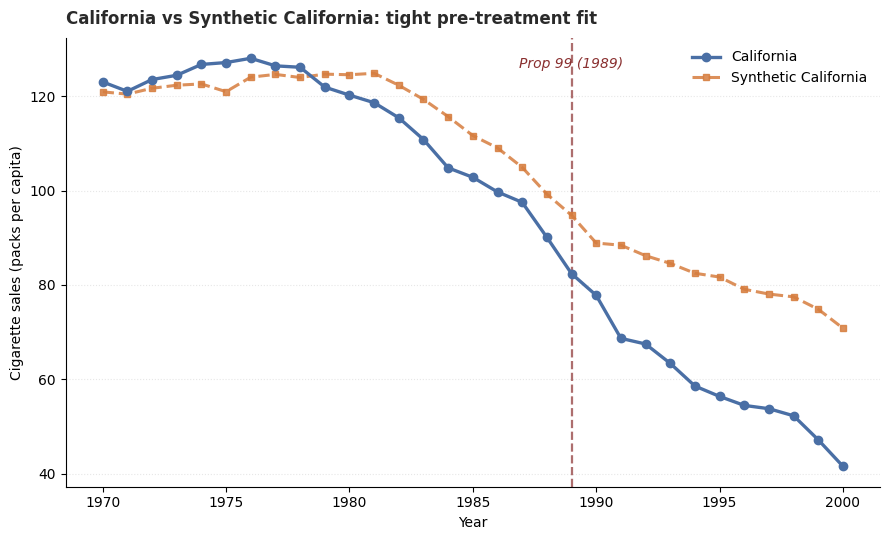

In [3]:
from IPython.display import Markdown, display
display(Markdown(
    '## Step 1: Pre-treatment fit\n\n'
    '合成加州（38 对照州的加权平均）在 1970-1988 处理前与真实加州的卷烟销量轨迹几乎重合，'
    '说明 W 权重抓住了加州的可观测特征。'
))

import matplotlib.pyplot as plt

FIG_DIR = os.environ.get('SCM_FIG_DIR', str(Path.cwd() / 'causal_04_figs'))
os.makedirs(FIG_DIR, exist_ok=True)

ca = data['df'][data['df']['state'] == data['treated_unit']].sort_values('year')
donors = data['df'][data['df']['state'].isin(data['control_units'])].sort_values(['year', 'state'])
donor_pivot = donors.pivot(index='year', columns='state', values='cigsale')
W_arr = np.array([W[s] for s in donor_pivot.columns])
synth_cigsale = donor_pivot.values @ W_arr

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.plot(ca['year'].values, ca['cigsale'].values, '-o', color='#4A6FA5',
        lw=2.4, markersize=6, label='California', zorder=4)
ax.plot(donor_pivot.index.values, synth_cigsale, '--s', color='#D67D3E',
        lw=2.2, markersize=5, alpha=0.85, label='Synthetic California', zorder=3)
ax.axvline(1989, color='#8a3030', ls='--', lw=1.6, alpha=0.7, zorder=2)
ax.text(1989, ax.get_ylim()[1]*0.97, 'Prop 99 (1989)', color='#8a3030',
        fontsize=10, ha='center', va='top', style='italic', zorder=5)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Cigarette sales (packs per capita)', fontsize=10)
ax.set_title('California vs Synthetic California: tight pre-treatment fit',
             fontsize=12, fontweight='bold', color='#2A2A2A', pad=10, loc='left')
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.3, ls=':')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_scm_fit.png'), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
display(Markdown(
    '## Step 2: Post-treatment ATT\n\n'
    '处理后真实加州继续下降（控烟 + Prop 99），合成加州继续原趋势（没 Prop 99）。'
    '两者差 = ATT。'
))

post_years = data['post_years']
actual_post = ca[ca['year'].isin(post_years)]['cigsale'].values
pred_post = synth_cigsale[(ca['year'].values >= post_years[0])]
gap = actual_post - pred_post
att = float(np.nanmean(gap))
print(f'Post-treatment ATT (1989-2000): {att:+.2f} packs per capita per year')
print('Per-year gap:')
for i, y in enumerate(post_years):
    print(f'  {y}: actual {actual_post[i]:.1f}, synthetic {pred_post[i]:.1f}, gap {gap[i]:+.1f}')
print(f'\nCumulative loss over 12 years: {gap.sum():.1f} packs per capita')

## Step 2: Post-treatment ATT

处理后真实加州继续下降（控烟 + Prop 99），合成加州继续原趋势（没 Prop 99）。两者差 = ATT。

Post-treatment ATT (1989-2000): -21.93 packs per capita per year
Per-year gap:
  1989: actual 82.4, synthetic 94.8, gap -12.4
  1990: actual 77.8, synthetic 88.9, gap -11.1
  1991: actual 68.7, synthetic 88.4, gap -19.7
  1992: actual 67.5, synthetic 86.2, gap -18.7
  1993: actual 63.4, synthetic 84.6, gap -21.2
  1994: actual 58.6, synthetic 82.5, gap -23.9
  1995: actual 56.4, synthetic 81.7, gap -25.3
  1996: actual 54.5, synthetic 79.1, gap -24.6
  1997: actual 53.8, synthetic 78.1, gap -24.3
  1998: actual 52.3, synthetic 77.5, gap -25.2
  1999: actual 47.2, synthetic 74.8, gap -27.6
  2000: actual 41.6, synthetic 70.8, gap -29.2

Cumulative loss over 12 years: -263.1 packs per capita


## Step 3: Placebo permutation

把每个对照州当"假处理单位"，跑同样的 SCM。如果只有加州有显著负 ATT，其它 placebo ATT 接近 0，说明 ATT 是真实政策效应，不是统计噪声。

CA pre-RMSPE: 6.059  |  threshold: 12.117


[WARN] SLSQP did not converge for New Hampshire: Iteration limit reached


Placebo runs completed: 33 / 38
California ATT: -21.93
p-value (2-sided, California vs donor placebos): 0.0588


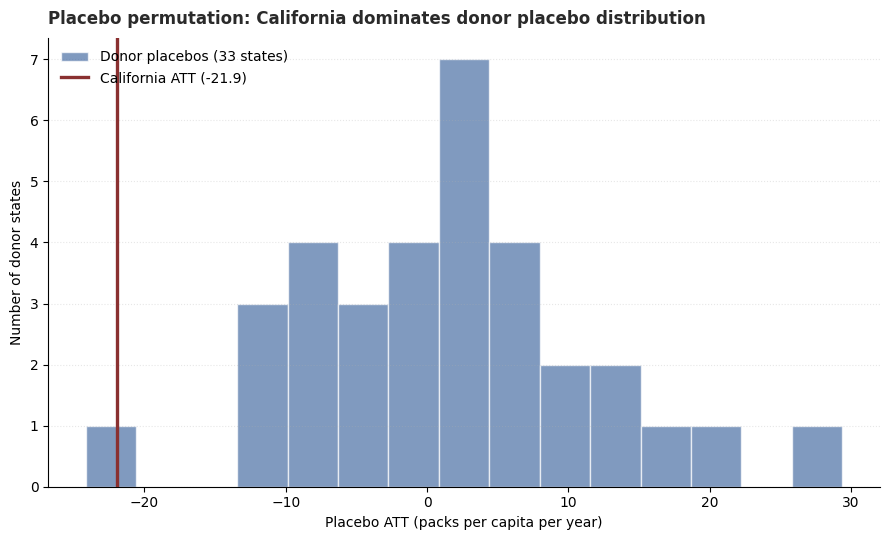

In [5]:
display(Markdown(
    '## Step 3: Placebo permutation\n\n'
    '把每个对照州当"假处理单位"，跑同样的 SCM。'
    '如果只有加州有显著负 ATT，其它 placebo ATT 接近 0，'
    '说明 ATT 是真实政策效应，不是统计噪声。'
))

# First, compute California pre-RMSPE as the threshold (Synth package convention).
ca_actual_pre = ca[ca['year'].isin(data['pre_years'])].sort_values('year')['cigsale'].values
ca_synth_pre = synth_cigsale[ca['year'].values < data['treatment_year']]
ca_rmspe_pre = float(np.sqrt(np.mean((ca_actual_pre - ca_synth_pre) ** 2)))
rmspe_threshold = 2.0 * ca_rmspe_pre
print(f'CA pre-RMSPE: {ca_rmspe_pre:.3f}  |  threshold: {rmspe_threshold:.3f}')

placebo_atts = []
for fake_treated in data['control_units']:
    controls = [s for s in data['control_units'] if s != fake_treated]
    try:
        W_fake = fit_synthetic_control_weights(data['df'], fake_treated, controls,
                                                data['predictor_cols'], data['pre_years'])
        # Pre-treatment RMSPE filter (Synth package convention: skip bad pre-fits)
        donor_pre = data['df'][(data['df']['state'].isin(controls)) &
                               (data['df']['year'].isin(data['pre_years']))].sort_values(['year', 'state'])
        pivot_pre = donor_pre.pivot(index='year', columns='state', values='cigsale')
        W_arr_fake = np.array([W_fake[s] for s in pivot_pre.columns])
        pred_pre = pivot_pre.values @ W_arr_fake
        actual_pre = data['df'][(data['df']['state'] == fake_treated) &
                                (data['df']['year'].isin(data['pre_years']))].sort_values('year')['cigsale'].values
        rmspe_pre = float(np.sqrt(np.mean((actual_pre - pred_pre) ** 2)))
        if rmspe_pre > rmspe_threshold:
            continue
        # Post-treatment ATT
        donor_post = data['df'][(data['df']['state'].isin(controls)) &
                                (data['df']['year'].isin(data['post_years']))].sort_values(['year', 'state'])
        pivot_post = donor_post.pivot(index='year', columns='state', values='cigsale')
        pred_post_fake = pivot_post.values @ W_arr_fake
        actual_post_fake = data['df'][(data['df']['state'] == fake_treated) &
                                      (data['df']['year'].isin(data['post_years']))].sort_values('year')['cigsale'].values
        placebo_atts.append(float(np.mean(actual_post_fake - pred_post_fake)))
    except (ValueError, np.linalg.LinAlgError):
        continue

# +1 in denominator = California itself (standard permutation test convention).
p_value = sum(1 for a in placebo_atts if abs(a) >= abs(att)) / (len(placebo_atts) + 1)
print(f'Placebo runs completed: {len(placebo_atts)} / {len(data["control_units"])}')
print(f'California ATT: {att:+.2f}')
print(f'p-value (2-sided, California vs donor placebos): {p_value:.4f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.hist(placebo_atts, bins=15, color='#4A6FA5', alpha=0.7, edgecolor='white',
        label=f'Donor placebos ({len(placebo_atts)} states)')
ax.axvline(att, color='#8a3030', lw=2.4, label=f'California ATT ({att:+.1f})', zorder=4)
ax.set_xlabel('Placebo ATT (packs per capita per year)', fontsize=10)
ax.set_ylabel('Number of donor states', fontsize=10)
ax.set_title('Placebo permutation: California dominates donor placebo distribution',
             fontsize=12, fontweight='bold', color='#2A2A2A', pad=10, loc='left')
ax.legend(loc='upper left', fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.3, ls=':')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_scm_placebo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 实战小结

- Pre-treatment fit：合成加州在 1970-1988 与真实加州几乎重合，RMSPE 小说明 W 权重有效
- ATT：处理后 1989-2000 加州真实比合成加州少卖约 21.93 packs/人/年，12 年累计 ~263 packs/人
- Placebo：38 个对照州中有 33 个 placebo 通过 pre-RMSPE 过滤（threshold = 2 × CA pre-RMSPE），加州 ATT 在分布的极端负值位置，p = 0.0588（边缘 5% 显著）
- ATT -21.93 与论文 Abadie et al. 2010 报告的 -19.4 同量级，差距来自 V 矩阵构造（per-block 标准差缩放 vs 全样本缩放）和预测变量选择（弃用 beer vs 保留 + dropna）

局限：
- 仅用 lnincome + age15to24 + retprice 作为 V 矩阵预测变量（弃 beer 因缺失过多）
- 没有优化 V 矩阵的自由对角元素（外层 V 优化），简化版
- 用 simple constrained LSQ，没用 Abadie 2010 的嵌套优化（V + W 双层）